In [21]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors, cm
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy.stats import bootstrap

In [22]:
# INPUT PARAMETERS
base_dir = f"../figures/hazard_figures"

output_dir = "../figures/hazard_figures/overload_analysis"
os.makedirs(output_dir, exist_ok=True)

In [23]:
lines_gdf = gpd.read_file('../outputs/table_lines_200m_update_remove_disconnected.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m_update_remove_disconnected.gpkg')
loads_gdf = gpd.read_file('../outputs/landuse_sites_gdf_add_bus.gpkg')
gens_gdf = gpd.read_file('../outputs/plant_update.gpkg')
basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")

overload_lines_df = pd.read_csv(f"{base_dir}/overloaded_lines_records.csv")
failed_lines_df = pd.read_csv(f"{base_dir}/failed_lines_records.csv")
failed_nodes_df = pd.read_csv(f"{base_dir}/failed_buses_records.csv")
# load_ratio_df = pd.read_csv(f"{base_dir}/load_served_ratio.csv")
load_status_df = pd.read_csv(f"{base_dir}/load_status_records.csv")
results_df = pd.read_csv(f"{base_dir}/percolation_overall_results.csv")


In [24]:
loads_gdf.head()

,element_type,osmid,nodes,landuse,name,name:en,operator,owner,plant:method,plant:output:electricity,...,name:th,addr:hamlet,port:type,ruins,addr:district:en,addr:province:en,addr:subdistrict:en,total_electricity_demand,BusID,geometry
0,way,876508089,"[8157751794, 8157751793, 8157751792, 815775179...",industrial,None,None,None,None,None,None,...,None,None,None,None,None,None,None,35.691332,NODEVN3590,"MULTIPOLYGON (((521908.382 994781.312, 521831...."
1,way,876286185,"[8155710983, 8155710982, 8155710981, 815571098...",industrial,None,None,None,None,None,None,...,None,None,None,None,None,None,None,35.691332,NODEVN3607,"MULTIPOLYGON (((517082.121 1012145.562, 517013..."
2,way,876286186,"[8155710990, 8155710989, 8155710988, 815571098...",industrial,None,None,None,None,None,None,...,None,None,None,None,None,None,None,146.050941,NODEVN3607,"MULTIPOLYGON (((516824.904 1012809.168, 516796..."
3,way,876508090,"[8157751806, 8157751805, 8157751804, 815775180...",industrial,None,None,None,None,None,None,...,None,None,None,None,None,None,None,35.691332,NODEVN2671,"MULTIPOLYGON (((531328.127 1014894.974, 531322..."
4,way,876286177,"[8155707958, 8155707957, 8155707956, 815570795...",industrial,None,None,None,None,None,None,...,None,None,None,None,None,None,None,35.691332,NODEVN2882,"MULTIPOLYGON (((534591.202 1016328.623, 534639..."


In [6]:
def assign_adm1_codes_with_ref_and_pcode(nodes_gdf, lines_gdf, loads_gdf, basemap):
    """
    Assign ADM1_EN, ADM1_REF, and ADM1_PCODE to nodes, lines, and loads by spatial overlay proportion.
    """
    nodes_gdf = nodes_gdf.to_crs(basemap.crs)
    lines_gdf = lines_gdf.to_crs(basemap.crs)
    loads_gdf = loads_gdf.to_crs(basemap.crs)

    nodes_gdf = gpd.sjoin(nodes_gdf, basemap[["ADM1_EN", "ADM1_REF", "ADM1_PCODE", "geometry"]], how="left", predicate="within")
    nodes_gdf.drop(columns=["index_right"], inplace=True)

    line_overlay = gpd.overlay(lines_gdf, basemap, how="intersection")
    line_overlay["length"] = line_overlay.geometry.length
    total_lengths = line_overlay.groupby("LineID")["length"].sum().rename("total")
    line_overlay = line_overlay.join(total_lengths, on="LineID")
    line_overlay["ratio"] = line_overlay["length"] / line_overlay["total"]
    major_parts = line_overlay[line_overlay["ratio"] > 0.6].copy()
    line_adm = major_parts[["LineID", "ADM1_EN", "ADM1_REF", "ADM1_PCODE"]].drop_duplicates()
    lines_gdf = lines_gdf.merge(line_adm, on="LineID", how="left")

    load_overlay = gpd.overlay(loads_gdf, basemap, how="intersection")
    load_overlay["area"] = load_overlay.geometry.area
    total_areas = load_overlay.groupby("osmid")["area"].sum().rename("total")
    load_overlay = load_overlay.join(total_areas, on="osmid")
    load_overlay["ratio"] = load_overlay["area"] / load_overlay["total"]
    major_parts = load_overlay[load_overlay["ratio"] > 0.6].copy()
    load_adm = major_parts[["osmid", "ADM1_EN", "ADM1_REF", "ADM1_PCODE"]].drop_duplicates()
    loads_gdf = loads_gdf.merge(load_adm, on="osmid", how="left")

    return nodes_gdf, lines_gdf, loads_gdf

In [7]:
nodes_gdf, lines_gdf, loads_gdf = assign_adm1_codes_with_ref_and_pcode(nodes_gdf, lines_gdf, loads_gdf, basemap)

C:\Users\mye500\AppData\Local\Temp\ipykernel_8592\3819892932.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  line_overlay["length"] = line_overlay.geometry.length
C:\Users\mye500\AppData\Local\Temp\ipykernel_8592\3819892932.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  load_overlay["area"] = load_overlay.geometry.area


In [ ]:
# def analyze_overloaded_lines(overloaded_lines_df, lines_gdf, threshold = 0.5, output_dir=None):
#     os.makedirs(output_dir, exist_ok=True)
    
#     # === Step 1: 统计每条线路超载次数 ===
#     overload_count = overloaded_lines_df.groupby("line_name").size().rename("overload_count").reset_index()
    
#     # 从 overloaded_lines_df 提取所有唯一的仿真组合
#     sim_combinations = overloaded_lines_df["fail_iter"].drop_duplicates()
#     # 真实参与仿真的总次数（成功且线路有结果）
#     num_simulations = sim_combinations.shape[0]

#     overload_count["overload_ratio"] = overload_count["overload_count"] / num_simulations
#     overload_count = overload_count.sort_values("overload_ratio", ascending=False)

#     # 保存统计表
#     overload_count.to_csv(os.path.join(output_dir, "overloaded_line_stats.csv"))

#     # === Step 2: 关键线路筛选 ===
#     critical_lines = overload_count[overload_count["overload_ratio"] >= threshold]
#     critical_lines.to_csv(os.path.join(output_dir, f"critical_lines_over_{int(threshold*100)}pct.csv"))

#     # === Step 3a: 可视化柱状图 ===
#     plt.figure(figsize=(8, 6))
#     top_lines = overload_count.head(10)
#     plt.bar(top_lines["line_name"], top_lines["overload_ratio"], color="tomato")
#     plt.ylabel("Overload frequency")
#     plt.xlabel("LineID (Top 10)")
#     plt.title("Top 10 line overload ratios")
#     plt.tight_layout()
#     plt.savefig(os.path.join(output_dir, "overload_bar_top10.png"), dpi=300)
#     plt.show()
#     plt.close()

#     # === Step 3b: 地图可视化 ===
#     lines_with_ratio = lines_gdf.merge(overload_count, how="left", left_on="LineID", right_on="line_name")
#     lines_with_ratio["overload_ratio"] = lines_with_ratio["overload_ratio"].fillna(0)

#     fig, ax = plt.subplots(1, 1, figsize=(12, 10))
#     lines_with_ratio.plot(column="overload_ratio", cmap="Reds", legend=True,
#                           linewidth=1, ax=ax)
#     ax.set_title("Line overload frequency map", fontsize=15)
#     plt.axis("off")
#     plt.savefig(os.path.join(output_dir, "overload_map.png"), dpi=300)
#     plt.show()
#     plt.close()

#     # === Step 4: 过载率 vs 线路长度 ===
#     if "Length" in lines_with_ratio.columns:
#         plt.figure(figsize=(8, 6))
#         plt.scatter(lines_with_ratio["Length"], lines_with_ratio["overload_ratio"], alpha=0.6)
#         plt.xlabel("Line Length (km)")
#         plt.ylabel("Overload Ratio")
#         plt.title("Overload Ratio vs. Line Length")
#         plt.grid(True)
#         plt.tight_layout()
#         plt.savefig(os.path.join(output_dir, "overload_vs_length.png"), dpi=300)
#         plt.show()

#     # === Step 5: 区域统计（如有）===
#     region_field = "ADM1_EN" if "ADM1_EN" in lines_with_ratio.columns else None
#     if region_field:
#         region_critical = lines_with_ratio[lines_with_ratio["overload_ratio"] >= threshold]
#         region_summary = region_critical.groupby(region_field).size().rename("critical_line_count").reset_index()
#         region_summary.to_csv(os.path.join(output_dir, "critical_line_count_by_region.csv"), index=False)

#     # === Step 6: Histogram of overload ratio bins (vs. total lines) ===
#     bins = np.arange(0.01, 1.01, 0.1)
#     lines_with_ratio["overload_ratio"] = lines_with_ratio["overload_ratio"].fillna(0)

#     total_lines_all = len(lines_with_ratio)
#     lines_positive = lines_with_ratio[lines_with_ratio["overload_ratio"] > 0]

#     counts, bin_edges = np.histogram(lines_positive["overload_ratio"], bins=bins)
#     bin_labels = [f"{round(bin_edges[i],1)}–{round(bin_edges[i+1],1)}" for i in range(len(counts))]
#     proportions = [f"{(c/total_lines_all*100):.2f}%" for c in counts]

#     plt.figure(figsize=(9, 6))
#     bars = plt.bar(bin_labels, counts, color="skyblue", edgecolor="lightgray")
#     plt.xlabel("Overload ratio interval (excl. 0)", fontsize=12)
#     plt.ylabel("Number of lines", fontsize=12)
#     plt.title("Overload ratio distribution (% of all lines)", fontsize=14)
#     plt.grid(axis="y", linestyle="--", alpha=0.7)

#     for bar, pct in zip(bars, proportions):
#         height = bar.get_height()
#         plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, pct,
#                  ha="center", va="bottom", fontsize=10, fontweight="bold")

#     plt.tight_layout()
#     plt.savefig(os.path.join(output_dir, "overload_ratio_hist_vs_all_lines.png"), dpi=300)
#     plt.show()


#     return overload_count, critical_lines, lines_with_ratio


In [ ]:
# overload_count, critical_lines, lines_with_ratio = analyze_overloaded_lines(overloaded_lines_df, lines_gdf, threshold=0.5, output_dir=output_dir)

In [8]:
# Merge overload ratio stats
# === Step 1: 统计每条线路超载次数 ===
overload_count = overload_lines_df.groupby("line_name").size().rename("overload_count").reset_index()
# 真实参与仿真的总次数（成功且线路有结果）
sim_combinations = overload_lines_df["fail_iter"].drop_duplicates()
num_simulations = sim_combinations.shape[0]

overload_count["overload_ratio"] = overload_count["overload_count"] / num_simulations
overload_count = overload_count.sort_values("overload_ratio", ascending=False)
overload_count.to_csv(os.path.join(output_dir, "overloaded_line_stats.csv"))

lines_gdf = lines_gdf.merge(overload_count.rename(columns={"line_name": "LineID"}), on="LineID", how="left")
lines_gdf["overload_ratio"] = lines_gdf["overload_ratio"].fillna(0)

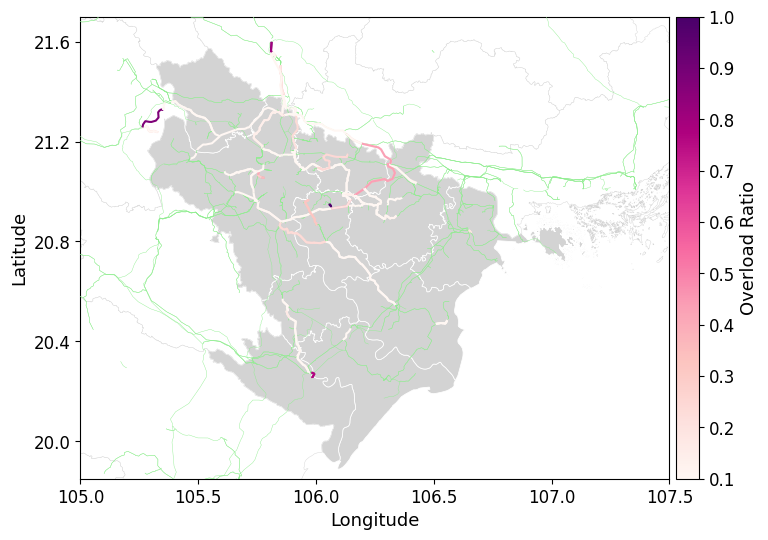

In [ ]:
# def plot_overload_by_adm_ref(lines_with_ratio, output_dir=None, basemap=None):
#     os.makedirs(output_dir, exist_ok=True)

#     # 统一坐标系
#     lines_with_ratio = lines_with_ratio.to_crs("EPSG:4326")
#     basemap = basemap.to_crs("EPSG:4326")

#     # 区域定义
#     pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104',
#                   'VN717','VN711','VN707','VN713','VN701','VN709']
#     target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
#     other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

#     # 统一色阶
#     vmin = lines_with_ratio["overload_ratio"].min()
#     vmax = lines_with_ratio["overload_ratio"].max()
#     norm = colors.Normalize(vmin=0.1, vmax=vmax)
#     cmap = plt.colormaps.get_cmap("RdPu")

#     overloaded = lines_with_ratio[lines_with_ratio["overload_ratio"] > 0]
#     non_overloaded = lines_with_ratio[lines_with_ratio["overload_ratio"] == 0]
    
#     fig, ax = plt.subplots(1, 1, figsize=(8, 6))

#     # 子图 1：Red River Delta
#     # ax.set_title("Red River Delta", fontsize=15)
#     ax.set_xlabel("Longitude", fontsize=13)
#     ax.set_ylabel("Latitude", fontsize=13)
#     ax.set_xlim(105, 107.5)
#     ax.set_ylim(19.85, 21.7)
#     ax.set_aspect('auto')
#     ax.tick_params(axis='both', labelsize=12)
#     target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.56, zorder=1)
#     other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=2)
#     non_overloaded.plot(ax=ax, color='lightgreen', linewidth=0.3, zorder=3)
#     overloaded.plot(ax=ax, column="overload_ratio", cmap=cmap, norm=norm, linewidth=1.5, zorder=4)

#     ax.set_aspect('auto')
#     ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
#     ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

#     # 色条
#     sm = cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm._A = []
#     cbar = fig.colorbar(sm, ax=ax, orientation="vertical", location='right', fraction=0.04, pad=0.01)
#     cbar.set_label("Overload Ratio", fontsize=13)
#     cbar.ax.tick_params(labelsize=12)

#     plt.savefig(os.path.join(output_dir, "overload_map_region_split.png"), dpi=600, bbox_inches="tight")
#     plt.show(fig)

# plot_overload_ratio_maps_by_region(lines_gdf, output_dir=output_dir, basemap=basemap)

In [9]:
def plot_overload_by_adm_ref(lines_with_ratio, output_dir=None, basemap=None):
    os.makedirs(output_dir, exist_ok=True)

    lines_with_ratio = lines_with_ratio.to_crs("EPSG:4326")
    basemap = basemap.to_crs("EPSG:4326")

    pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104',
                  'VN717','VN711','VN707','VN713','VN701','VN709']
    target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
    other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

    vmin = lines_with_ratio["overload_ratio"].min()
    vmax = lines_with_ratio["overload_ratio"].max()

    bounds = [0, 0.2, 0.4, 0.6, 0.8, vmax + 0.01]
    cmap = ListedColormap(plt.cm.YlOrRd(np.linspace(0.3, 1, len(bounds)-1)))
    norm = BoundaryNorm(bounds, cmap.N)

    overloaded = lines_with_ratio[lines_with_ratio["overload_ratio"] > 0]
    non_overloaded = lines_with_ratio[lines_with_ratio["overload_ratio"] == 0]

    fig, ax = plt.subplots(1, 1, figsize=(8.5, 6))

    # ax.set_title("Red River Delta", fontsize=15)
    ax.set_xlabel("Longitude", fontsize=13)
    ax.set_ylabel("Latitude", fontsize=13)
    ax.set_xlim(105, 107.5)
    ax.set_ylim(19.85, 21.7)
    ax.set_aspect('auto')
    ax.tick_params(axis='both', labelsize=12)
    target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, zorder=1)
    other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=2)
    non_overloaded.plot(ax=ax, color='lightgreen', linewidth=0.5, alpha=0.5, zorder=3)
    overloaded.plot(ax=ax, column="overload_ratio", cmap=cmap, norm=norm, linewidth=1.5, zorder=4)

    # lines_with_ratio.plot(ax=ax1, column="overload_ratio", cmap=cmap, norm=norm, linewidth=1.5, legend=False, zorder=3)

    ax.set_aspect('auto')
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    tick_locs = [(bounds[i] + bounds[i+1]) / 2 for i in range(len(bounds)-1)]
    tick_labels = [f"{bounds[i]:.1f}-{bounds[i+1]:.1f}" for i in range(len(bounds)-1)]
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", location='right', fraction=0.04, ticks=tick_locs, pad=0.03)
    cbar.ax.set_yticklabels(tick_labels, fontsize=12)
    cbar.set_label("Overload ratio", fontsize=13)

    plt.savefig(os.path.join(output_dir, "overload_map_region_split_fixed_bins.png"), dpi=600, bbox_inches="tight")
    plt.show(fig)

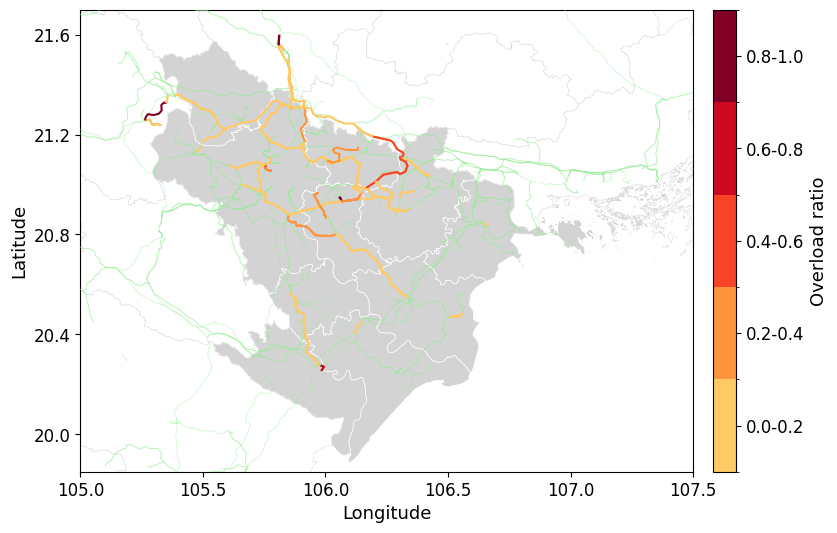

In [10]:
plot_overload_by_adm_ref(lines_gdf, output_dir=output_dir, basemap=basemap)

In [11]:
def plot_load_failure_probability(load_status_df, loads_gdf, results_df, basemap, output_path=None):
    # === Ensure ID formats match ===
    # loads_gdf["osmid"] = pd.to_numeric(loads_gdf["osmid"], errors="coerce").astype("Int64")
    # load_status_df["load_id"] = pd.to_numeric(load_status_df["load_id"], errors="coerce").astype("Int64")

    # === Filter out iterations with failed powerflow ===
    successful_iters = results_df.loc[results_df["powerflow_success"], "fail_iter"]
    load_status_df = load_status_df[load_status_df["fail_iter"].isin(successful_iters)]

    # === Calculate failure probability ===
    failure_stats = (
        load_status_df.groupby("load_id")["served"]
        .mean()
        .reset_index(name="served_ratio")
    )
    failure_stats["failure_probability"] = 1 - failure_stats["served_ratio"]

    # === Merge & fill missing with 0 ===
    loads_gdf = loads_gdf.merge(failure_stats[["load_id", "failure_probability", "served_ratio"]],
                                left_on="osmid", right_on="load_id", how="left")
    loads_gdf["failure_probability"] = loads_gdf["failure_probability"].fillna(0)

    # === Basemap preprocessing ===
    loads_gdf = loads_gdf.to_crs("EPSG:4326")
    basemap = basemap.to_crs("EPSG:4326")

    pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
    target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
    other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

    # === Split data ===
    always_served_loads = loads_gdf[loads_gdf["failure_probability"] == 0]
    failed_loads = loads_gdf[loads_gdf["failure_probability"] > 0]

    # === Colormap ===
    cmap = cm.YlOrRd
    norm = colors.Normalize(vmin=0, vmax=1)

    # === Plot ===
    fig, ax = plt.subplots(1, 1, figsize=(8.5, 6))

    # ax.set_title("Load Failure Probability", fontsize=15)
    ax.set_xlim(105, 107.5)
    ax.set_ylim(19.85, 21.7)
    ax.set_xlabel("Longitude", fontsize=13)
    ax.set_ylabel("Latitude", fontsize=13)
    ax.tick_params(axis='both', labelsize=12)

    # Basemap
    target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, zorder=1)
    other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=0)

    # # Plot zero-failure loads (fixed color)
    # always_served_loads.plot(ax=ax, color='lightgreen', zorder=2, label="Failure p = 0")

    # # Plot partial failures (gradient color)
    # failed_loads.plot(ax=ax, column="failure_probability", cmap=cmap, norm=norm, zorder=3)
    loads_gdf.plot(ax=ax, column="failure_probability", cmap=cmap, norm=norm, zorder=3)

    # Colorbar for only failed loads
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.04, pad=0.02)
    cbar.set_label("Failure probability", fontsize=13)
    cbar.ax.tick_params(labelsize=12)

    ax.legend(loc='lower right', fontsize=12)

    if output_path:
        plt.savefig(output_path, dpi=600, bbox_inches="tight")
        print(f"✓ Saved to {output_path}")

    plt.show()

    return loads_gdf


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


✓ Saved to ../figures/hazard_figures/overload_analysis


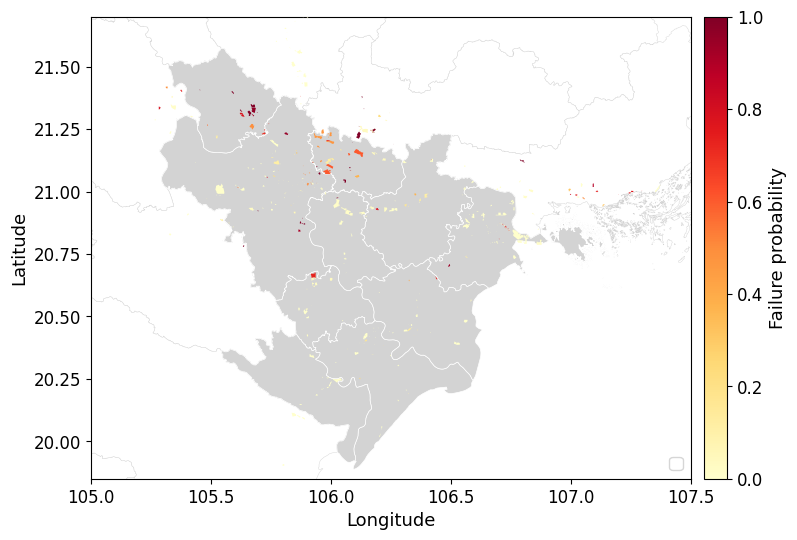

In [12]:
loads_gdf_update = plot_load_failure_probability(load_status_df, loads_gdf, results_df, basemap=basemap, output_path=output_dir)

In [13]:
# Inputs
net_dir = base_dir

# Step 1: Load successful fail_iters
passed_iters = (
    results_df[results_df["powerflow_success"] == True]["fail_iter"]
    .str.extract(r"fail_iter_(\d+)")
    .astype(int)
    .squeeze()
    .tolist()
)

print(f"✓ Found {len(passed_iters)} successful iterations")

# Step 2: Calculate failure ratio for each
fail_stats = []

for i in passed_iters:
    filepath = os.path.join(net_dir, f"net_results_fail_iter{i}.xlsx")
    try:
        xls = pd.read_excel(filepath, sheet_name=None)
        df_res = xls["res_load"]
        total = len(df_res)
        zero_count = (df_res["p_mw"] == 0).sum()
        ratio = zero_count / total if total > 0 else None
        fail_stats.append({
            "fail_iter": i,
            "total_loads": total,
            "zero_p_mw": zero_count,
            "zero_ratio": ratio
        })
    except Exception as e:
        fail_stats.append({
            "fail_iter": i,
            "total_loads": None,
            "zero_p_mw": None,
            "zero_ratio": None,
            "error": str(e)
        })

df_fail_ratios = pd.DataFrame(fail_stats)

✓ Found 81 successful iterations


In [14]:
df_fail_ratios

,fail_iter,total_loads,zero_p_mw,zero_ratio
0,1,1378,102,0.074020
1,2,1378,143,0.103774
2,3,1378,99,0.071843
3,4,1378,110,0.079826
4,5,1378,115,0.083454
...,...,...,...,...
76,96,1378,77,0.055878
77,97,1378,72,0.052250
78,98,1378,69,0.050073
79,99,1378,104,0.075472


In [15]:
df_fail_ratios['zero_ratio'].mean()

0.07316920210001972

✓ Found 81 successful iterations


C:\Users\mye500\AppData\Local\Temp\ipykernel_8592\1726554723.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(median_order, rotation=45, ha="right", fontsize=13)


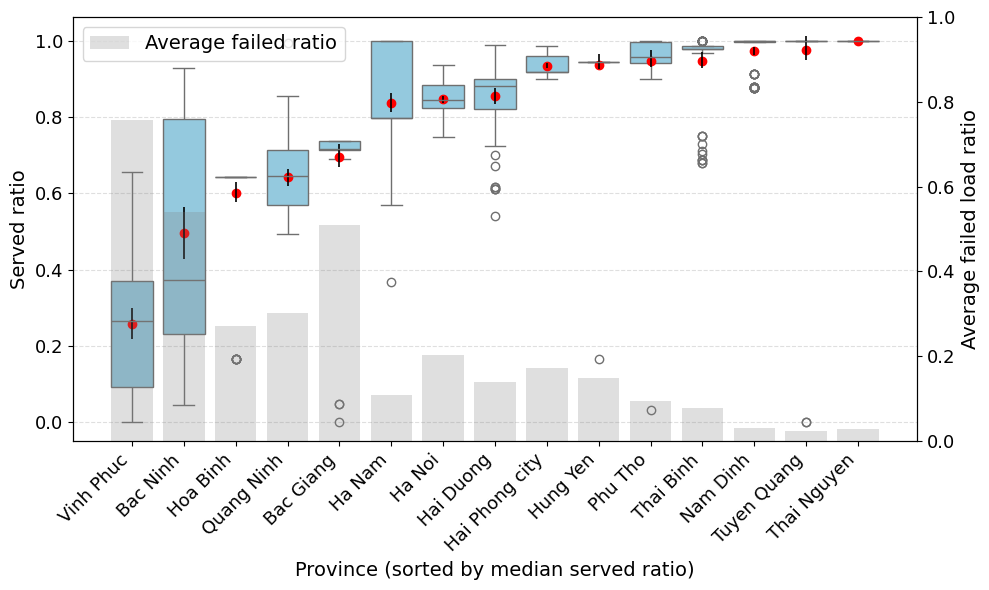

In [16]:
def analyze_served_ratio_by_adm(loads_gdf, load_status_df, results_df, net_dir, output_dir):
    # === Step 1: 读取成功迭代 ===
    passed_iters = (
        results_df[results_df["powerflow_success"] == True]["fail_iter"]
        .str.extract(r"fail_iter_(\d+)")
        .astype(int)
        .squeeze()
        .tolist()
    )
    passed_iters_str = [f"fail_iter_{i}" for i in passed_iters]
    print(f"✓ Found {len(passed_iters_str)} successful iterations")

    all_records = []

    for i in passed_iters:
        filepath = os.path.join(net_dir, f"net_results_fail_iter{i}.xlsx")
        try:
            xls = pd.read_excel(filepath, sheet_name=None)
            df_load = xls["load"]
            df_res = xls["res_load"]
        except Exception as e:
            print(f"✗ Skipping {filepath}: {e}")
            continue

        df = df_load[["name", "p_mw"]].merge(
            df_res[["p_mw"]], left_index=True, right_index=True, suffixes=("", "_res")
        ).rename(columns={"name": "load_id", "p_mw": "p_mw", "p_mw_res": "res_p_mw"})

        # Merge ADM1
        id_adm_df = loads_gdf[["osmid", "ADM1_EN"]].rename(columns={"osmid": "load_id"})
        df = pd.merge(df, id_adm_df, on="load_id", how="left").dropna(subset=["ADM1_EN"])

        grouped = df.groupby("ADM1_EN")[["res_p_mw", "p_mw"]].sum()
        grouped["served_ratio"] = grouped["res_p_mw"] / grouped["p_mw"]
        grouped["fail_iter"] = f"fail_iter_{i}"
        all_records.append(grouped.reset_index()[["ADM1_EN", "fail_iter", "served_ratio"]])

    df_all = pd.concat(all_records, ignore_index=True)
    df_avg = df_all.groupby("ADM1_EN")["served_ratio"].mean().reset_index(name="served_ratio_mean")
    median_order = df_avg.sort_values(by="served_ratio_mean", ascending=True)["ADM1_EN"]

    # === Step 3: Prepare average failed ratio per region ===
    id_adm_df = loads_gdf[['osmid', 'ADM1_EN']].rename(columns={'osmid': 'load_id'})
    status_with_adm = pd.merge(load_status_df, id_adm_df, on='load_id', how='left')
    status_with_adm['served'] = status_with_adm['served'].astype(bool)
    status_with_adm = status_with_adm[status_with_adm['fail_iter'].isin(passed_iters_str)]

    failure_ratio = (
        status_with_adm
        .groupby(['fail_iter', 'ADM1_EN'])['served']
        .apply(lambda x: (~x).sum() / len(x))
        .reset_index(name='failed_ratio')
    )

    avg_failed_ratio = (
        failure_ratio
        .groupby('ADM1_EN')['failed_ratio']
        .mean()
        .reindex(median_order)
        .fillna(0)
    )

    # 仅保留有 failed load 的 ADM1
    adm_with_failures = failure_ratio[failure_ratio["failed_ratio"] > 0]["ADM1_EN"].unique()
    df_all = df_all[df_all["ADM1_EN"].isin(adm_with_failures)]
    df_avg = df_avg[df_avg["ADM1_EN"].isin(adm_with_failures)]
    median_order = df_avg.sort_values(by="served_ratio_mean", ascending=True)["ADM1_EN"]
    avg_failed_ratio = avg_failed_ratio.loc[median_order]

    # === Step 4: 绘图 ===
    fig, ax1 = plt.subplots(figsize=(10, 6))

    sns.boxplot(
        data=df_all,
        x="ADM1_EN",
        y="served_ratio",
        order=median_order,
        ax=ax1,
        color="skyblue"
    )

    means = df_all.groupby("ADM1_EN")["served_ratio"].mean()

    for xtick, adm1 in enumerate(median_order):
        group = df_all[df_all["ADM1_EN"] == adm1]["served_ratio"].values
        if len(group) > 1:
            ci = bootstrap((group,), np.mean, confidence_level=0.95, n_resamples=1000, method="basic")
            ci_low, ci_high = ci.confidence_interval
            ax1.plot(xtick, means[adm1], 'ro')
            ax1.vlines(xtick, ci_low, ci_high, color='black', linewidth=1.2)
        else:
            ax1.plot(xtick, means[adm1], 'ro')

    # global_median = df_all["served_ratio"].median()
    # ax1.axhline(global_median, color="green", linestyle="--", linewidth=1.2, label="Global median")
    ax1.set_ylabel("Served ratio", fontsize=14)
    ax1.set_xlabel("Province (sorted by median served ratio)", fontsize=14)
    ax1.set_xticklabels(median_order, rotation=45, ha="right", fontsize=13)
    ax1.tick_params(axis='y', labelsize=13)
    ax1.grid(axis="y", linestyle="--", alpha=0.4)
    # ax1.legend(loc="upper left")

    # 替换右轴为平均失败比例
    ax2 = ax1.twinx()
    ax2.bar(median_order, avg_failed_ratio.values, alpha=0.25, color="gray", label="Average failed ratio")
    ax2.set_ylabel("Average failed load ratio", fontsize=14)
    ax2.tick_params(axis='y', labelsize=13)
    ax2.set_ylim(0, 1)
    ax2.legend(loc="upper left", fontsize=14)

    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, "load_served_ratio_boxplot_by_adm1.png"), dpi=600, bbox_inches='tight')
    plt.show()

    return df_all, df_avg, failure_ratio, avg_failed_ratio


df_all, df_avg, failure_ratio, avg_failed_ratio = analyze_served_ratio_by_adm(
    loads_gdf=loads_gdf,
    load_status_df=load_status_df,
    results_df=results_df,
    net_dir=base_dir,
    output_dir=output_dir
)

In [17]:
df_avg

,ADM1_EN,served_ratio_mean
2,Bac Giang,0.695754
5,Bac Ninh,0.495688
21,Ha Nam,0.837995
22,Ha Noi,0.846544
24,Hai Duong,0.854863
25,Hai Phong city,0.934645
28,Hoa Binh,0.600878
29,Hung Yen,0.936315
35,Nam Dinh,0.973615
39,Phu Tho,0.947840


In [18]:
avg_failed_ratio

ADM1_EN
Vinh Phuc         0.756173
Bac Ninh          0.539095
Hoa Binh          0.271605
Quang Ninh        0.303195
Bac Giang         0.508488
Ha Nam            0.109568
Ha Noi            0.201955
Hai Duong         0.139918
Hai Phong city    0.171664
Hung Yen          0.148736
Phu Tho           0.095165
Thai Binh         0.078368
Nam Dinh          0.031077
Tuyen Quang       0.024691
Thai Nguyen       0.028148
Name: failed_ratio, dtype: float64

In [19]:
def export_summary_table(df_avg, avg_failed_ratio, loads_gdf, output_dir):
    # Convert avg_failed_ratio Series to DataFrame
    df_failed = avg_failed_ratio.reset_index().rename(columns={'failed_ratio': 'avg_failed_ratio'})

    # Merge df_avg 和 df_failed
    summary_df = pd.merge(df_avg, df_failed, on='ADM1_EN', how='outer')

    # 添加每个ADM1的负荷总数（osmid去重计数）
    load_counts = (
        loads_gdf[loads_gdf["ADM1_EN"].isin(summary_df["ADM1_EN"])]
        .groupby("ADM1_EN")["osmid"]
        .nunique()
        .reset_index()
        .rename(columns={"osmid": "total_loads"})
    )

    summary_df = pd.merge(summary_df, load_counts, on="ADM1_EN", how="left")
    summary_df["served_ratio_mean"] = (summary_df["served_ratio_mean"] * 100).round(1)
    summary_df["avg_failed_ratio"] = (summary_df["avg_failed_ratio"] * 100).round(1)
    summary_df = summary_df.sort_values(by="served_ratio_mean", ascending=True)

    # 输出为 Excel 文件
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, "adm1_served_summary.xlsx")
    summary_df.to_excel(output_path, index=False)

    return summary_df, output_path

summary_df, output_path = export_summary_table(
    df_avg=df_avg,
    avg_failed_ratio=avg_failed_ratio,
    loads_gdf=loads_gdf,
    output_dir=output_dir
)

In [20]:
summary_df

,ADM1_EN,served_ratio_mean,avg_failed_ratio,total_loads
14,Vinh Phuc,25.8,75.6,16
1,Bac Ninh,49.6,53.9,30
6,Hoa Binh,60.1,27.2,4
10,Quang Ninh,64.3,30.3,34
0,Bac Giang,69.6,50.8,16
2,Ha Nam,83.8,11.0,16
3,Ha Noi,84.7,20.2,120
4,Hai Duong,85.5,14.0,27
5,Hai Phong city,93.5,17.2,84
7,Hung Yen,93.6,14.9,21
